In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 71.6 MB/s eta 0:00:00


In [18]:
import os
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
# NLP utilities
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
# Word2Vec
from gensim.models import Word2Vec
# Download NLTK resources (run once)
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('punkt_tab')

print("✅ Imports and NLTK downloads completed.")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ Imports and NLTK downloads completed.


**A**) Fetch data

In [7]:
!pip install kaggle -q
from google.colab import files
files.upload()  # choose kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fatsedz","key":"654e24d8482a4b00f71d965031995d5f"}'}

In [8]:
os.makedirs("/root/.kaggle", exist_ok=True)
os.replace("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)
print("kaggle.json set up ✅")

!kaggle datasets download mexwell/fake-reviews-dataset -p /content -q --unzip
print(os.listdir("/content"))

kaggle.json set up ✅
Dataset URL: https://www.kaggle.com/datasets/mexwell/fake-reviews-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
['.config', 'fake reviews dataset.csv', 'sample_data']


In [11]:
# 1-----------------Load dataset-----------------

In [10]:
csv_path = "/content/fake reviews dataset.csv"
df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (40432, 4)
Columns: ['category', 'rating', 'label', 'text_']


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [12]:
# 2-----------------Basic cleaning: drop missing text or labels-----------------
df = df.dropna(subset=["text_", "label"])
# Map labels to binary values
# CG = 1 (fake), OR = 0 (real)
label_map = {"CG": 1, "OR": 0}
df["label_encoded"] = df["label"].map(label_map)

# Sanity check
print("Unique encoded labels:", df["label_encoded"].unique())
print("Number of rows after cleaning:", len(df))

df[["label", "label_encoded"]].head()


Unique encoded labels: [1 0]
Number of rows after cleaning: 40432


,label,label_encoded
0,CG,1
1,CG,1
2,CG,1
3,CG,1
4,CG,1


In [14]:
# 3 -----------------Define features (X) and target (y)-----------------
X_text = df["text_"].astype(str).values
y = df["label_encoded"].values
print("Number of samples:", len(X_text))
print("Example text:", X_text[0][:300])
print("Example label:", y[0])
# 4 -----------------Train/Test split-----------------
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train samples:", len(X_train_text))
print("Test samples :", len(X_test_text))

Number of samples: 40432
Example text: Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty
Example label: 1
Train samples: 32345
Test samples : 8087


**B**) Text preprocessing

In [19]:
# 5-----------------Text preprocessing: clean, tokenize, remove stopwords, lemmatize-----------------
english_stopwords = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r"<.*?>", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in english_stopwords and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

print(clean_text("This is a <b>simple</b> TEST!! With HTML, numbers 123 and punctuation..."))

# Apply cleaning to train and test sets
X_train_clean = [clean_text(t) for t in X_train_text]
X_test_clean = [clean_text(t) for t in X_test_text]

print("Number of cleaned train samples:", len(X_train_clean))
print("Sample cleaned text:", X_train_clean[0][:300])


simple test html number punctuation
Number of cleaned train samples: 32345
Sample cleaned text: second book series character story woven together story lot heart second book also filled lot angst something look forward


In [20]:
# 6)----------------- TF-IDF vectorization-----------------
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
)
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)
print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape :", X_test_tfidf.shape)


TF-IDF train shape: (32345, 20000)
TF-IDF test shape : (8087, 20000)


In [21]:
# 7) Train several classifiers on TF-IDF features
#Logistic Regression | SVM | Random Forest | XGBoost۵
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        n_jobs=-1
    ),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    )
}

results_tfidf = []
for name, model in models.items():
    print(f"\n🚀 Training {name} on TF-IDF features...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results_tfidf.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })
# Put results into a DataFrame, sorted by F1-score
metrics_tfidf_df = pd.DataFrame(results_tfidf).sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

metrics_tfidf_df



🚀 Training Logistic Regression on TF-IDF features...

🚀 Training Linear SVM on TF-IDF features...

🚀 Training Random Forest on TF-IDF features...

🚀 Training XGBoost on TF-IDF features...


,Model,Accuracy,Precision,Recall,F1-score
0,Linear SVM,0.909113,0.906988,0.911699,0.909338
1,Logistic Regression,0.898108,0.900075,0.895622,0.897843
2,Random Forest,0.871028,0.878979,0.860500,0.869641
3,XGBoost,0.858662,0.877015,0.834281,0.855115


In [22]:
# 8) Train Linear SVM on TF-IDF
print("Training Linear SVM on TF-IDF features...")

svm_clf = LinearSVC()
svm_clf.fit(X_train_tfidf, y_train)
y_pred_svm = svm_clf.predict(X_test_tfidf)
svm_acc  = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm)
svm_rec  = recall_score(y_test, y_pred_svm)
svm_f1   = f1_score(y_test, y_pred_svm)

print("\n Linear SVM Performance (TF-IDF):")
print(f"Accuracy :  {svm_acc:.4f}")
print(f"Precision: {svm_prec:.4f}")
print(f"Recall   : {svm_rec:.4f}")
print(f"F1-score : {svm_f1:.4f}\n")

# Detailed classification report
print(" Classification Report:")
print(classification_report(y_test, y_pred_svm, digits=4))


Training Linear SVM on TF-IDF features...

 Linear SVM Performance (TF-IDF):
Accuracy :  0.9091
Precision: 0.9070
Recall   : 0.9117
F1-score : 0.9093

 Classification Report:
              precision    recall  f1-score   support

           0     0.9113    0.9065    0.9089      4044
           1     0.9070    0.9117    0.9093      4043

    accuracy                         0.9091      8087
   macro avg     0.9091    0.9091    0.9091      8087
weighted avg     0.9091    0.9091    0.9091      8087



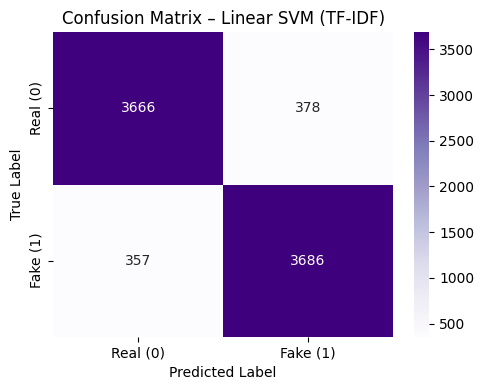

In [23]:
# Confusion Matrix for Linear SVM (TF-IDF)
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Real (0)', 'Fake (1)'],
    yticklabels=['Real (0)', 'Fake (1)']
)
plt.title("Confusion Matrix – Linear SVM (TF-IDF)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [24]:
# 9) Word2Vec: prepare tokenized texts (using the same clean_text but as tokens)
def text_to_tokens(text: str):
    text = re.sub(r"<.*?>", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z\\s]", " ", text)
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in english_stopwords and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

train_tokens = [text_to_tokens(t) for t in X_train_text]
test_tokens  = [text_to_tokens(t) for t in X_test_text]
print("Example tokens:", train_tokens[0][:20])

Example tokens: ['second', 'book', 'series', 'character', 'story', 'woven', 'together', 'story', 'lot', 'heart', 'second', 'book', 'also', 'filled', 'lot', 'angst', 'something', 'look', 'forward']


In [25]:
# Train a Word2Vec model on training tokens
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10
)
print("✅ Word2Vec model trained.")
print("Vocabulary size:", len(w2v_model.wv))
# Show embedding example
sample_word = list(w2v_model.wv.index_to_key)[0]
print(sample_word, "=>", w2v_model.wv[sample_word][:10])


✅ Word2Vec model trained.
Vocabulary size: 17501
book => [-0.02444769  0.11576676  0.21713266  0.41750285  0.06720765 -0.74003947
  0.69667643  0.66919523 -0.20156743 -0.10255568]


In [26]:
def sentence_to_vec(tokens, model, vector_size=100):
    """
    Convert a list of tokens into a single sentence vector
    by averaging the Word2Vec embeddings of the tokens.
    """
    vectors = []
    for t in tokens:
        if t in model.wv:
            vectors.append(model.wv[t])
    if len(vectors) == 0:
        # no known tokens, return zero vector
        return np.zeros(vector_size)
    else:
        return np.mean(vectors, axis=0)

# Build feature matrices for train and test using Word2Vec embeddings
X_train_w2v = np.vstack([sentence_to_vec(tokens, w2v_model, 100) for tokens in train_tokens])
X_test_w2v  = np.vstack([sentence_to_vec(tokens, w2v_model, 100) for tokens in test_tokens])

print("Word2Vec train shape:", X_train_w2v.shape)
print("Word2Vec test shape :", X_test_w2v.shape)

Word2Vec train shape: (32345, 100)
Word2Vec test shape : (8087, 100)


In [27]:
# 10) Logistic Regression on Word2Vec sentence embeddings
print("🚀 Training Logistic Regression on Word2Vec embeddings...")
w2v_clf = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)
# Train the model on Word2Vec sentence vectors
w2v_clf.fit(X_train_w2v, y_train)
# Predict on the test set
y_pred_w2v = w2v_clf.predict(X_test_w2v)
# Compute evaluation metrics
w2v_acc  = accuracy_score(y_test, y_pred_w2v)
w2v_prec = precision_score(y_test, y_pred_w2v)
w2v_rec  = recall_score(y_test, y_pred_w2v)
w2v_f1   = f1_score(y_test, y_pred_w2v)

print("\n📊 Logistic Regression Performance (Word2Vec):")
print(f"Accuracy :  {w2v_acc:.4f}")
print(f"Precision: {w2v_prec:.4f}")
print(f"Recall   : {w2v_rec:.4f}")
print(f"F1-score : {w2v_f1:.4f}\n")
print("📄 Classification Report (Word2Vec + Logistic Regression):")
print(classification_report(y_test, y_pred_w2v, digits=4))

🚀 Training Logistic Regression on Word2Vec embeddings...

📊 Logistic Regression Performance (Word2Vec):
Accuracy :  0.8598
Precision: 0.8594
Recall   : 0.8603
F1-score : 0.8598

📄 Classification Report (Word2Vec + Logistic Regression):
              precision    recall  f1-score   support

           0     0.8601    0.8593    0.8597      4044
           1     0.8594    0.8603    0.8598      4043

    accuracy                         0.8598      8087
   macro avg     0.8598    0.8598    0.8598      8087
weighted avg     0.8598    0.8598    0.8598      8087



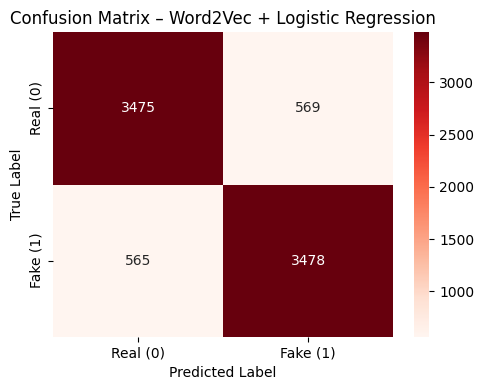

In [28]:
cm_w2v = confusion_matrix(y_test, y_pred_w2v)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_w2v,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Real (0)', 'Fake (1)'],
    yticklabels=['Real (0)', 'Fake (1)']
)
plt.title("Confusion Matrix – Word2Vec + Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

t-SNE embedding shape: (8087, 2)


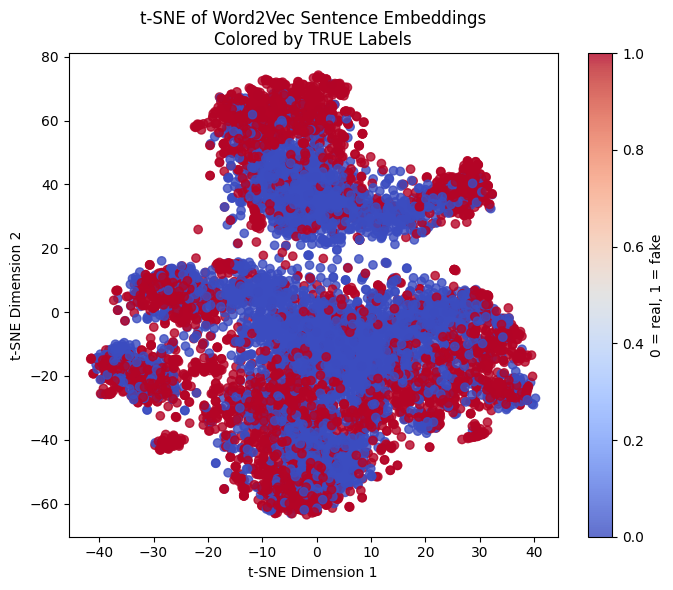

In [29]:
# 11) t-SNE on Word2Vec sentence embeddings (test set)
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=40,
    learning_rate="auto",
    init="random"
)
X_test_tsne = tsne.fit_transform(X_test_w2v)
print("t-SNE embedding shape:", X_test_tsne.shape)
# Plot t-SNE colored by TRUE labels
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_test_tsne[:, 0],
    X_test_tsne[:, 1],
    c=y_test,
    cmap="coolwarm",
    alpha=0.8
)
plt.title("t-SNE of Word2Vec Sentence Embeddings\nColored by TRUE Labels")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(scatter, label="0 = real, 1 = fake")
plt.tight_layout()
plt.show()


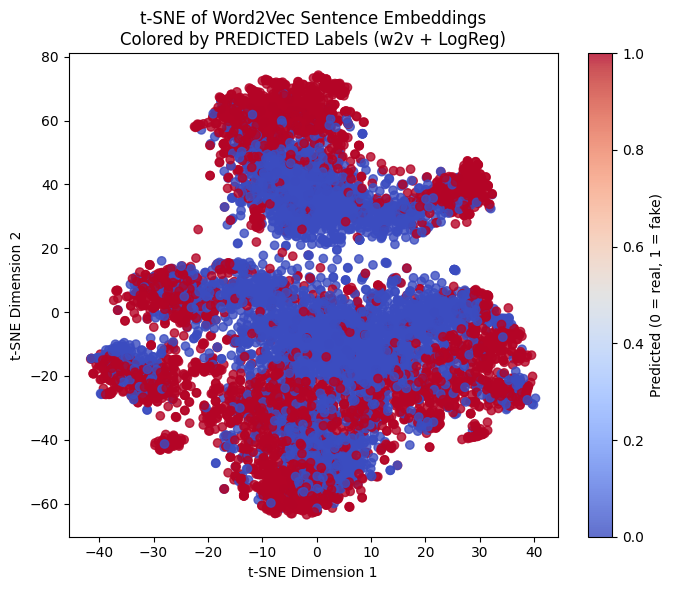

In [30]:
# Plot t-SNE colored by PREDICTED labels (Word2Vec model)
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_test_tsne[:, 0],
    X_test_tsne[:, 1],
    c=y_pred_w2v,
    cmap="coolwarm",
    alpha=0.8
)

plt.title("t-SNE of Word2Vec Sentence Embeddings\nColored by PREDICTED Labels (w2v + LogReg)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(scatter, label="Predicted (0 = real, 1 = fake)")
plt.tight_layout()
plt.show()


In [33]:
best_tfidf_model_name = metrics_tfidf_df.iloc[0]["Model"]
best_tfidf_acc  = metrics_tfidf_df.iloc[0]["Accuracy"]
best_tfidf_prec = metrics_tfidf_df.iloc[0]["Precision"]
best_tfidf_rec  = metrics_tfidf_df.iloc[0]["Recall"]
best_tfidf_f1   = metrics_tfidf_df.iloc[0]["F1-score"]

# Combine both methods into one comparison table
comparison_df = pd.DataFrame({
    "Embedding": ["TF-IDF", "Word2Vec"],
    "Best Model": [best_tfidf_model_name, "Logistic Regression"],
    "Accuracy":  [best_tfidf_acc,  w2v_acc],
    "Precision": [best_tfidf_prec, w2v_prec],
    "Recall":    [best_tfidf_rec,  w2v_rec],
    "F1-score":  [best_tfidf_f1,   w2v_f1],
    "Vector Type": ["Sparse (up to 20k dims)", "Dense (100 dims)"],
    "Notes": [
        "High performance, simple, excellent for sparse text",
        "Captures semantic meaning but needs large data"
    ]
})

print("📊 Final Comparison: TF-IDF vs Word2Vec")
comparison_df

📊 Final Comparison: TF-IDF vs Word2Vec


,Embedding,Best Model,Accuracy,Precision,Recall,F1-score,Vector Type,Notes
0,TF-IDF,Linear SVM,0.909113,0.906988,0.911699,0.909338,Sparse (up to 20k dims),"High performance, simple, excellent for sparse..."
1,Word2Vec,Logistic Regression,0.859775,0.859402,0.860252,0.859827,Dense (100 dims),Captures semantic meaning but needs large data
